# **Machine Learning Project**






## Setup for the models

In [106]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
df = pd.read_csv("student_dropout_cleaned.csv")
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score

print(" All libraries imported successfully!")


 All libraries imported successfully!


In [107]:
import pandas as pd

df = pd.read_csv("student_dropout_cleaned.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.columns)
print(df.head())## Viewing data information

Dataset Shape: (10000, 19)

First 5 rows:
Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='str')
   Student_ID   Age  Gender  Family_Income Internet_Access  \
0           1  22.1    Male        25000.0             Yes   
1           2  20.7    Male        25000.0             Yes   
2           3  22.4    Male        40183.0             Yes   
3           4  24.4    Male        29740.5             Yes   
4           5  20.5  Female        25319.0             Yes   

   Study_Hours_per_Day  Attendance_Rate  Assignment_Delay_Days  \
0                 3.36             86.1                      2   
1                 4.30             68.0                      2   
2                 4.40             70

In [108]:
X = df.drop("Dropout", axis=1)
y = df["Dropout"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (10000, 18)
Target shape: (10000,)


In [109]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (8000, 18)
Testing data: (2000, 18)


In [110]:
print(f"data dimensions: {df.shape}") #row and column distribution of data

data dimensions: (10000, 19)


In [111]:
#top 10 rows of data
df.head(10)

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,29740.5,Yes,4.00,82.2,2,38.6,No,No,5.5,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
5,6,20.5,Male,25000.0,Yes,4.11,89.1,2,47.1,No,Yes,6.0,2.52,2.72,2.69,Year 3,Business,Bachelor,0
6,7,24.5,Male,25000.0,Yes,3.00,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0
7,8,22.7,Female,25000.0,Yes,2.12,86.4,1,34.0,No,Yes,6.5,1.79,1.14,1.14,Year 1,Arts,High School,0
8,9,20.0,Male,57413.0,Yes,4.07,97.5,3,52.1,No,No,4.2,3.08,2.81,2.81,Year 1,CS,High School,0
9,10,22.2,Female,44930.0,Yes,2.98,82.2,1,19.7,No,No,6.7,1.59,1.73,1.73,Year 1,Science,Master,0


In [112]:
print(f"--- DATA INFORMATION---\n")
df.info()

--- DATA INFORMATION---

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          10000 non-null  float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    10000 non-null  float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           10000 non-null  float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  fl

In [113]:
print(f"--- STATS ---")
df.describe().round(3)

--- STATS ---


,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5000.500,21.026,37945.410,4.014,81.737,1.800,30.179,5.507,2.308,2.300,2.299,0.235
std,2886.896,2.140,20065.697,1.263,8.221,1.344,11.919,1.721,1.062,1.074,1.073,0.424
min,1.000,17.000,25000.000,0.500,38.200,0.000,5.000,1.000,0.000,0.000,0.000,0.000
25%,2500.750,19.500,25000.000,3.210,76.400,1.000,21.900,4.400,1.550,1.520,1.520,0.000
50%,5000.500,21.000,29740.500,4.000,81.800,2.000,30.200,5.500,2.350,2.350,2.350,0.000
75%,7500.250,22.500,43361.750,4.810,87.300,3.000,38.400,6.600,3.120,3.150,3.150,0.000
max,10000.000,29.600,316601.000,8.980,100.000,8.000,74.900,10.000,4.000,4.000,4.000,1.000




---


# DATA PREPROCESSING


---



This section includes checking for missing values, duplicate values, encoding/removing features, and one hot encoding for the categorical features.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# 1. Load dataset
df = pd.read_csv("student_dropout_cleaned.csv")

# 2. Separate features and target
X = df.drop("Dropout", axis=1)
y = df["Dropout"]

# 3. Convert categorical columns to numerical
X = pd.get_dummies(X, drop_first=True)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# 4. Split data - 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# 5. Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# 7. Train model
model.fit(X_train_scaled, y_train)

print("\nLogistic Regression model trained successfully!")

# 8. Predictions
y_pred = model.predict(X_test_scaled)

# 9. Prediction probabilities
y_prob = model.predict_proba(X_test_scaled)

print("\nPredictions:")
print(y_pred[:20])

print("\nPrediction Probabilities:")
print(y_prob[:10])

# 10. Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("\n========== MODEL RESULTS ==========")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
y_prob_positive = model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob_positive)

print("ROC-AUC Score:", roc_auc)

C:\Users\laptop\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


ValueError: could not convert string to float: 'Female'


Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87      1545
           1       0.00      0.00      0.00       455

    accuracy                           0.77      2000
   macro avg       0.39      0.50      0.44      2000
weighted avg       0.60      0.77      0.67      2000



C:\Users\laptop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\laptop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\laptop\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

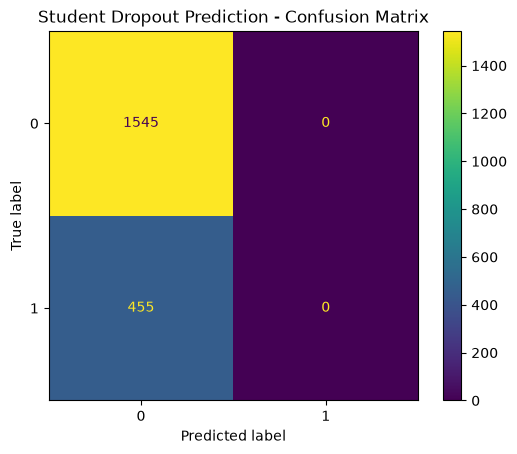

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Student Dropout Prediction - Confusion Matrix")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
plt.show()

In [ ]:
print(f"--- MISSING VALUES ---")
print(df.isnull().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

--- MISSING VALUES ---
Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

Training data: (8000, 18)
Testing data: (2000, 18)


In [ ]:
model = LogisticRegression(max_iter=1000)

print("\nLogistic Regression model created!")


Logistic Regression model created!


In [ ]:
df.tail(10) #last 10 rows of data set

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
9990,9991,24.2,Male,35589.0,Yes,1.62,74.2,0,28.7,No,No,8.1,0.00,0.13,0.13,Year 1,Arts,PhD,1
9991,9992,21.4,Male,49322.0,No,4.81,93.2,2,43.1,No,Yes,5.5,2.14,2.37,2.30,Year 3,Business,Bachelor,0
9992,9993,22.5,Female,41354.0,Yes,5.82,72.1,3,36.7,Yes,No,7.4,3.13,3.41,3.43,Year 4,Business,High School,1
9993,9994,17.7,Female,25000.0,Yes,2.06,79.9,1,24.1,No,Yes,6.1,1.37,1.20,1.15,Year 2,CS,Bachelor,0
9994,9995,23.6,Female,25000.0,Yes,3.96,98.9,3,40.1,No,No,5.6,1.43,1.95,1.93,Year 2,Arts,Bachelor,0
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0
9999,10000,22.4,Female,76796.0,Yes,4.95,83.7,1,15.5,Yes,No,7.9,2.17,2.20,2.20,Year 1,Arts,Master,0


In [ ]:
print(f"duplicate: {df.duplicated().sum()}") #duplicate data

duplicate: 0


In [ ]:
# Separate features and target
X = df.drop("Dropout", axis=1)
y = df["Dropout"]

# Convert categorical/text columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

# Scale the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully!")

# Predictions
y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred[:20])

# Prediction probabilities
y_prob = model.predict_proba(X_test)

print("\nPrediction Probabilities:")
print(y_prob[:10])

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
model.fit(X_train, y_train)


Features shape: (10000, 25)
Target shape: (10000,)

Training data: (8000, 25)
Testing data: (2000, 25)

Logistic Regression model trained successfully!

Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1]

Prediction Probabilities:
[[0.89681714 0.10318286]
 [0.77274624 0.22725376]
 [0.91610051 0.08389949]
 [0.72769064 0.27230936]
 [0.53770313 0.46229687]
 [0.94423185 0.05576815]
 [0.98075221 0.01924779]
 [0.69305249 0.30694751]
 [0.68268813 0.31731187]
 [0.64956922 0.35043078]]

Model Accuracy: 0.8145

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1529
           1       0.68      0.40      0.50       471

    accuracy                           0.81      2000
   macro avg       0.76      0.67      0.70      2000
weighted avg       0.80      0.81      0.80      2000



,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
import joblib

joblib.dump(model, "dropout_model.pkl")
joblib.dump(scaler, "dropout_scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Model and preprocessing files saved successfully!")

Model and preprocessing files saved successfully!


In [ ]:
df.head(10)

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,29740.5,Yes,4.00,82.2,2,38.6,No,No,5.5,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
5,6,20.5,Male,25000.0,Yes,4.11,89.1,2,47.1,No,Yes,6.0,2.52,2.72,2.69,Year 3,Business,Bachelor,0
6,7,24.5,Male,25000.0,Yes,3.00,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0
7,8,22.7,Female,25000.0,Yes,2.12,86.4,1,34.0,No,Yes,6.5,1.79,1.14,1.14,Year 1,Arts,High School,0
8,9,20.0,Male,57413.0,Yes,4.07,97.5,3,52.1,No,No,4.2,3.08,2.81,2.81,Year 1,CS,High School,0
9,10,22.2,Female,44930.0,Yes,2.98,82.2,1,19.7,No,No,6.7,1.59,1.73,1.73,Year 1,Science,Master,0


In [ ]:
#train-test split: 80-20
#80% data: training
#20% data: testing
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
#random_state=42 ensures same split every time you run.

Training samples : 8000
Testing  samples : 2000
